In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)  # none은 제한값 자리(몇개 열까지 보여줄까)

# 집에서의 경로: r'C:\Users\soohok402\내 드라이브\Github\AI_Data_exhibition\sample_data.csv'

df = pd.read_csv(r'C:\Users\soohok402\내 드라이브\Github\AI_Data_exhibition\sample_data.csv')


In [ ]:
# ============================================================
# 1. 기본 구조 확인
# ============================================================
# - 데이터 크기(shape), 컬럼명, 자료형 확인
print(f"데이터 크기: {df.shape}")
print()
print(f"자료형: \n{df.dtypes}")  # row_id, station_id만 object, 나머지는 수치형
print()

# - 데이터 일부(head) 확인
# print(df.head())
# print()

# - 기술통계(describe) 확인: 결과는 #1
print(df.describe(include = 'all'))  # include = 'all'은 비수치형자료도 포함 의미
print()

# mean >> 50%(median)인 변수가 많음, 시각화 필요
skew = df.select_dtypes(include = 'number').skew().sort_values(ascending = False)
print(skew)  # 왜도는 양수면 우측꼬리 긴 우편향, 절대값 > 1부터는 왜도가 있다고 봄


cat_area                            11.925271
wsarea                               7.034706
sfc_rain_1h                          6.748821
target_maxrise_6h                    6.722000
wl_t_minus_6h                        4.216577
wl_t_minus_24h                       4.216417
wl_t_minus_3h                        4.215208
wl_t_minus_1h                        4.215061
wl_t                                 4.214140
wl_t_minus_12h                       4.214098
station_id                           4.053096
sfc_rain_6h                          3.546411
stream_order                         2.889338
imerg_rain_1h                        2.696310
sfc_rain_24h                         2.114252
imerg_rain_6h                        1.934988
mean_elevation                       1.927923
imerg_rain_24h                       1.708837
radar_reflectivity_ge20_fraction     1.459540
urban_ratio                          1.387752
radar_reflectivity_mean              1.139866
radar_reflectivity_p95            

AttributeError: 'numpy.ndarray' object has no attribute 'boxplot'

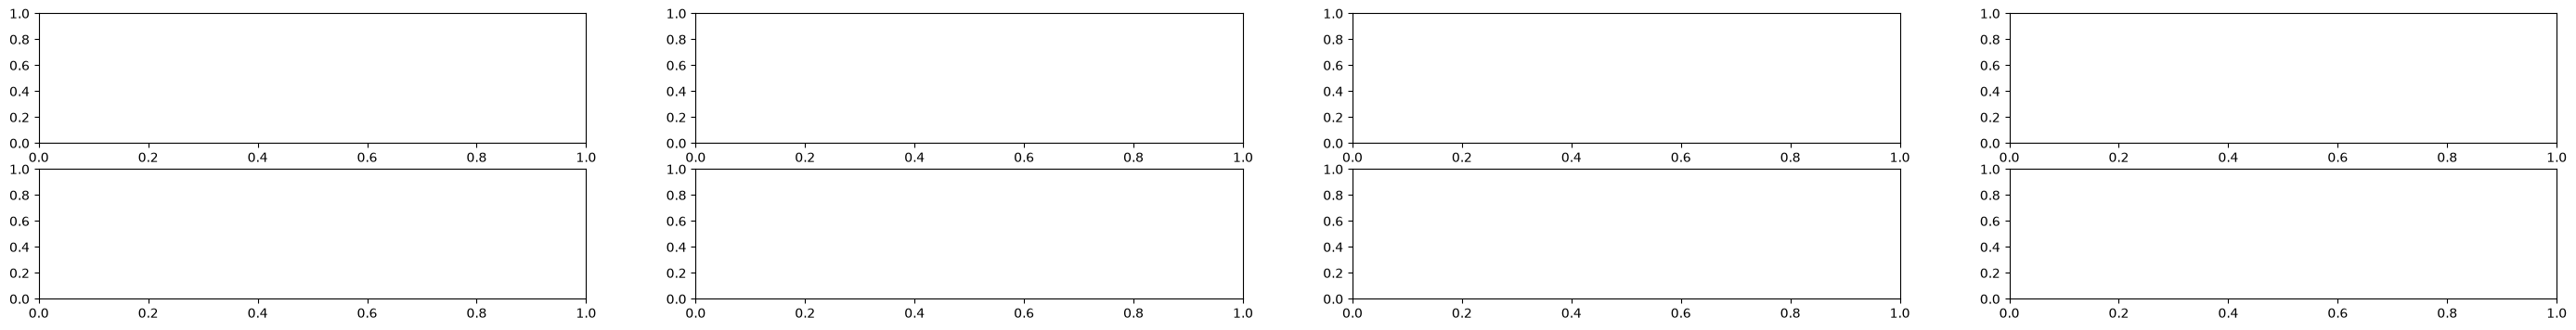

In [ ]:
# mean >> 50%(median)인 변수가 많음, 시각화 필요
skew = df.select_dtypes(include = 'number').skew().sort_values(ascending = False)
print(skew)  # 왜도는 양수면 우측꼬리 긴 우편향, 절대값 > 1부터는 왜도가 있다고 봄

# 박스플롯과 히스토그램 그리기
import matplotlib.pyplot as plt

cols = ['cat_area',
        'wsarea',
        'wl_t',
        'sfc_rain_1h',
        'imerg_rain_1h',
        'radar_reflectivity_p95',
        'target_maxrise_6h'
        ]

fig, axes = plt.subplots(
    (len(cols)+3)//4,   # 행 개수
    4,                  # 열 개수
    figsize = (5 * len(cols), 4)) # 전체 크기

axes = axes.flatten()  # 2행 이상일때는 axes가 2차원 배열을 가지므로 1차원으로 변경

for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()



for col in cols:
    plt.figure(figsize = (6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.ylabel(col)
    plt.show()


In [ ]:
# ============================================================
# 2. 데이터 품질 확인
# ============================================================
# - 중복 데이터 확인
# - 결측치 개수 및 비율 확인
# - 이상치 후보 확인


In [ ]:
# ============================================================
# 3. 변수 분포 확인
# ============================================================
# - 수위, 강우, 유역환경 변수의 분포 확인
# - Target(target_maxrise_6h) 분포 확인
# - 왜도, 극단값 등 분포 특성 확인

In [ ]:
# ============================================================
# 4. 시계열 구조 및 강우사상 경계 확인
# ============================================================
# - 관측소별 timestamp 정렬
# - 관측시점 간 시간간격(diff) 확인
# - 시계열 연속성 확인
# - 시간간격을 기준으로 강우사상별 event_id 생성
# ※ 샘플데이터에서는 일부 행만 제공되므로 실제 경계 판단은 본데이터에서 수행

In [ ]:
# ============================================================
# 5. 독립변수와 Target 간 관계 확인
# ============================================================
# - 수위 변수와 Target 관계 확인
# - 강우 변수와 Target 관계 확인
# - 유역환경 변수와 Target 관계 확인
# - 상관계수 및 시각화를 통해 주요 변수 후보 탐색